In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
data_dir = 'data/original_data'  # Replace with the path to your main directory
img_height = 224
img_width = 224
batch_size = 32
epochs = 30  # Adjust as needed
validation_split = 0.2  # Percentage of data for validation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split  
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Assuming you have subdirectories for each class
    subset='training',
    shuffle=True,
    seed=42
)

Found 6318 images belonging to 25 classes.


In [5]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1567 images belonging to 25 classes.


In [6]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
class_counts = np.bincount(train_generator.classes)
print(f"Class labels: {class_labels}")
print(f"Number of classes: {num_classes}")
print(f"Class counts: {class_counts}")

Class labels: ['Acrylic', 'Artificial_fur', 'Artificial_leather', 'Blended', 'Chenille', 'Corduroy', 'Cotton', 'Crepe', 'Denim', 'Felt', 'Fleece', 'Leather', 'Linen', 'Lut', 'Nylon', 'Polyester', 'Satin', 'Silk', 'Suede', 'Terrycloth', 'Unclassified', 'Utilities', 'Velvet', 'Viscose', 'Wool']
Number of classes: 25
Class counts: [  39    4   10 1316   42   77 1882   84  519   13  106   52   61   13
  183  724   77  160   16   96  394    7   36  119  288]


In [7]:
from collections import Counter

counter = Counter(train_generator.classes)
max_count = float(max(counter.values()))
class_weights = {class_id: max_count / count for class_id, count in counter.items()}
print(class_weights)

{np.int32(0): 48.256410256410255, np.int32(1): 470.5, np.int32(2): 188.2, np.int32(3): 1.4300911854103344, np.int32(4): 44.80952380952381, np.int32(5): 24.441558441558442, np.int32(6): 1.0, np.int32(7): 22.404761904761905, np.int32(8): 3.626204238921002, np.int32(9): 144.76923076923077, np.int32(10): 17.754716981132077, np.int32(11): 36.19230769230769, np.int32(12): 30.852459016393443, np.int32(13): 144.76923076923077, np.int32(14): 10.28415300546448, np.int32(15): 2.5994475138121547, np.int32(16): 24.441558441558442, np.int32(17): 11.7625, np.int32(18): 117.625, np.int32(19): 19.604166666666668, np.int32(20): 4.776649746192893, np.int32(21): 268.85714285714283, np.int32(22): 52.27777777777778, np.int32(23): 15.815126050420169, np.int32(24): 6.534722222222222}


In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [11]:
model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # Adjust learning rate as needed
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,            # Stop after 10 epochs of no improvement
    min_delta=0.001,        # Minimum change to be considered an improvement
    mode='min',             # We want the validation loss to minimize
    verbose=1,              # Print a message when it stops
    restore_best_weights=True # Restore model weights from the epoch with the best val_loss
)

class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, accuracy_threshold=0.90, val_accuracy_threshold=0.90):
        super().__init__()
        self.accuracy_threshold = accuracy_threshold
        self.val_accuracy_threshold = val_accuracy_threshold
        print(f"Accuracy Threshold Callback initialized: Train Acc >= {accuracy_threshold*100}% OR Val Acc >= {val_accuracy_threshold*100}%")

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')

        if current_acc is None or current_val_acc is None:
            print("Warning: 'accuracy' or 'val_accuracy' not found in logs. Cannot check thresholds.")
            return

        if current_acc >= self.accuracy_threshold or current_val_acc >= self.val_accuracy_threshold:
            print(f"\nEpoch {epoch+1}: Reached desired accuracy threshold!")
            print(f"  Train Acc: {current_acc:.4f}, Val Acc: {current_val_acc:.4f}")
            self.model.stop_training = True

In [14]:
my_callbacks = [
    AccuracyThresholdCallback(accuracy_threshold=0.90, val_accuracy_threshold=0.90),
    early_stopping_callback
]

Accuracy Threshold Callback initialized: Train Acc >= 90.0% OR Val Acc >= 90.0%


In [15]:
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,  
        verbose=1,
        class_weight=class_weights,
        callbacks=my_callbacks
    )

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.1143 - loss: 20.9753 - val_accuracy: 0.2266 - val_loss: 2.3747
Epoch 2/30
  1/197 ━━━━━━━━━━━━━━━━━━━━ 1:59 609ms/step - accuracy: 0.1250 - loss: 14.6394

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 198ms/step - accuracy: 0.1250 - loss: 14.6394 - val_accuracy: 0.2389 - val_loss: 2.3393
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.2615 - loss: 10.5663 - val_accuracy: 0.2930 - val_loss: 2.1345
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 197ms/step - accuracy: 0.3125 - loss: 5.9279 - val_accuracy: 0.3203 - val_loss: 2.0797
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.3367 - loss: 9.2702 - val_accuracy: 0.3483 - val_loss: 1.9159
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 194ms/step - accuracy: 0.3438 - loss: 6.6642 - val_accuracy: 0.3438 - val_loss: 1.9069
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.3893 - loss: 8.0072 - val_accuracy: 0.3919 - val_loss: 1.8040
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.2500 - loss: 6.9025 - val_accuracy: 0.3874 - val_loss: 1.8102
Epoch 9/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.4116 - loss: 6.7685 - val_accur

In [16]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 834ms/step - accuracy: 0.4023 - loss: 1.5649
Validation Loss: 1.3342
Validation Accuracy: 0.5260


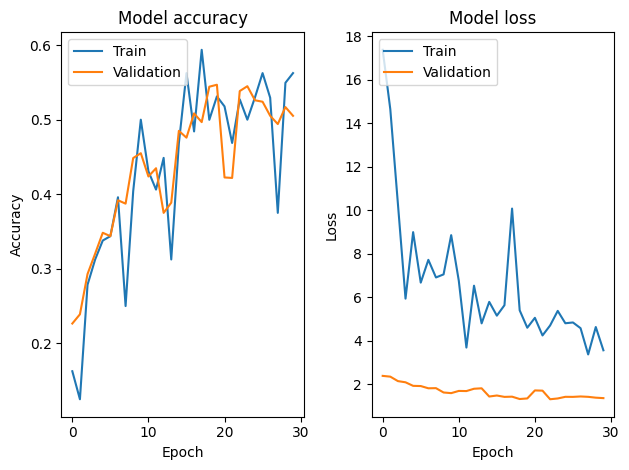

In [17]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
model.save('models/whole_fabric_texture_model_1.h5')

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
model_path = "models/whole_fabric_texture_model_1.h5"
model_1 = tf.keras.models.load_model(model_path)

In [20]:
# --- 3. Make Predictions on the Validation Set ---
print("Making predictions on the validation set...")
# Predict probabilities for each class
y_pred_probs = model_1.predict(validation_generator, steps=validation_generator.samples // batch_size + 1)
# Convert probabilities to class labels (index of the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the generator
# The generator provides labels in the order it processes the data
y_true = validation_generator.classes

Making predictions on the validation set...
49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 868ms/step


In [22]:
class_names = list(validation_generator.class_indices.keys())
import numpy as np

# Get unique classes actually present
unique_classes = np.unique(y_true)

# Map those to names
class_names_filtered = [class_names[i] for i in unique_classes]

# Print report
print(classification_report(y_true, y_pred, target_names=class_names_filtered, labels=unique_classes, digits=4))

                    precision    recall  f1-score   support

           Acrylic     0.2963    0.8889    0.4444         9
Artificial_leather     0.1111    1.0000    0.2000         2
           Blended     0.6667    0.1884    0.2938       329
          Chenille     0.4667    0.7000    0.5600        10
          Corduroy     0.4130    1.0000    0.5846        19
            Cotton     0.6632    0.5404    0.5955       470
             Crepe     0.3659    0.7500    0.4918        20
             Denim     0.7985    0.8295    0.8137       129
              Felt     0.3333    0.6667    0.4444         3
            Fleece     0.5682    0.9615    0.7143        26
           Leather     0.1875    0.7500    0.3000        12
             Linen     0.3421    0.8667    0.4906        15
               Lut     0.6000    1.0000    0.7500         3
             Nylon     0.2710    0.9333    0.4200        45
         Polyester     0.6571    0.3833    0.4842       180
             Satin     0.2353    0.6316

In [23]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


--- Confusion Matrix ---
[[  8   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  6   5  62   7   5  84   8   6   0   6  14   7   1  30  14   6   2   6
    1  16   0   1  26  16]
 [  0   0   0   7   1   1   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0  19   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [ 10   4  18   0  15 254   4  15   0   7  10  11   0  46  15   2   9   1
    0   4   0   0  38   7]
 [  0   0   0   0   0   2  15   0   0   0   1   0   0   0   0   0   0   0
    0   1   0   0   1   0]
 [  0   0   2   0   2   6   0 107   0   0   1   4   0   0   0   0   0   0
    1   1   0   0   2   3]
 [  0   0   0   0   0   0   0   0   2   0   1   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   1   0   0   0   0  25   0   0   0   0   0   0

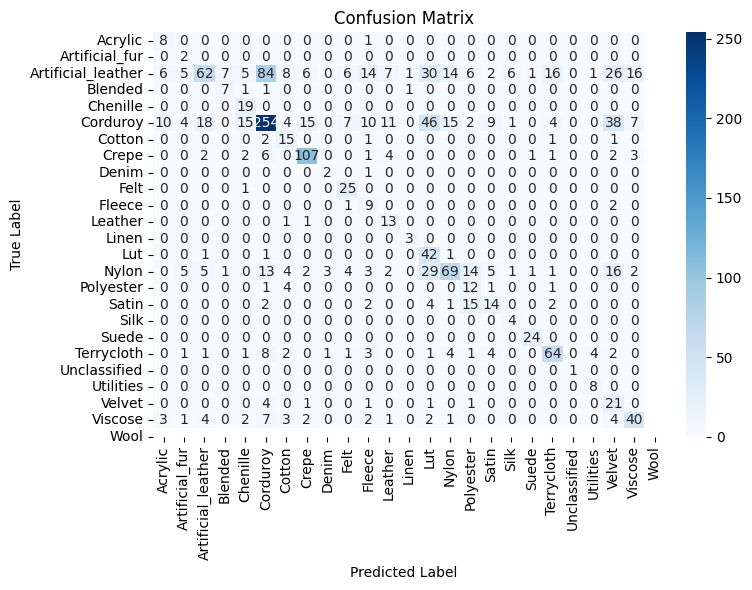

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()